## Implementação de um Percepetron Simples

In [39]:
import numpy as np
import matplotlib.pyplot as plt

In [40]:
def build_dataset(x, w, b = 0, noise = 0):
    return w*x + b + noise* np.random.randn(x.shape[0])

In [41]:
def forward(inputs, w, b):
    return (w * inputs) + b

In [42]:
def mse(y_target, y_pred):
    return (y_target - y_pred)**2

In [43]:
def backpropagation(inputs, output, target, w, b , lr):
    dw = lr*(-2*inputs*(target - output)).mean()
    db = lr*(-2*(target - output)).mean()

    w -= dw
    b -= db
    return w, b

In [ ]:
def fit(inputs, target, w, b, epochs = 200, lr = 0.001):
    
    for epoch in range(epochs):

        output = forward(inputs, w, b)

        loss = np.mean(mse(target, output))
        
        w, b = backpropagation(inputs, output, target, w, b, lr)

        if(epoch + 1) % (epochs/10) == 0:
            print(f'Epoch: [{epoch + 1} / {epochs}] Loss: [{loss}]')
    
    return w, b

In [87]:

x_test = np.arange(-10, 10, 2)
y_test_nn = build_dataset(x_test, w= 1.8, b=32)

In [88]:
w = np.random.randn(1)
b = np.zeros(1)

In [89]:
w, b = fit(x_test, y_test_nn, w, b, epochs = 500, lr = 0.005)
print(f'w: {w[0]}, b: {b[0]}')

Epoch: [50 / 500] Loss: [383.36147072717193]
Epoch: [100 / 500] Loss: [144.6795268790667]
Epoch: [150 / 500] Loss: [54.601641261042346]
Epoch: [200 / 500] Loss: [20.606503855183103]
Epoch: [250 / 500] Loss: [7.776835848277746]
Epoch: [300 / 500] Loss: [2.9349556934106613]
Epoch: [350 / 500] Loss: [1.1076439171840513]
Epoch: [400 / 500] Loss: [0.418021658735538]
Epoch: [450 / 500] Loss: [0.15776018308866227]
Epoch: [500 / 500] Loss: [0.05953824364854991]
w: 1.792574415923377, b: 31.75473091402136


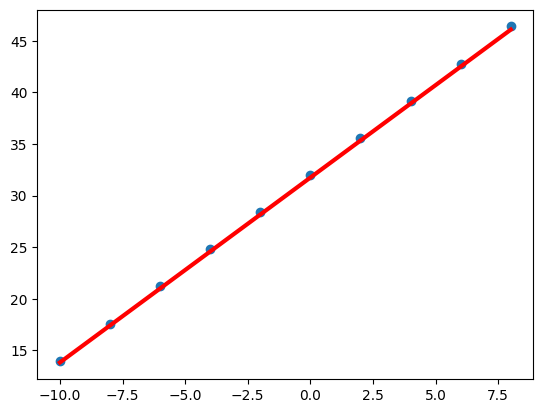

In [90]:
plt.scatter(x_test, y_test_nn)
plt.plot(x_test,build_dataset(x_test, w, b), 'r', lw=3 )